In [25]:
import sympy as sp
import numpy as np
import math
from scipy.optimize import brentq, fsolve

In [26]:
g_num = 9.81
h_num = 35.0
H_num = 150.0
D_num = 8.0
t_num = 0.1

M_num = 0
J_num = 0
c_num = 30e3

E_num = 210e9
rho_num = 7850.0
rho_f_num = 1025.0
Ca_num = 0
Cm_num = 1 + Ca_num
T_num = M_num * g_num

Di_num = D_num - 2.0*t_num
A_num = math.pi/4.0 * (D_num**2 - Di_num**2)
I_num = math.pi/64.0 * (D_num**4 - Di_num**4)

In [27]:
# -----------------------------
# Symbols
# -----------------------------
z, omega = sp.symbols('z omega', real=True)
E, I, T = sp.symbols('E I T', positive=True, real=True)
rho, A = sp.symbols('rho A', positive=True, real=True)
rho_f, Ca, D = sp.symbols('rho_f Ca D', positive=True, real=True)
h, H = sp.symbols('h H', positive=True, real=True)
J, Mtip, c = sp.symbols('J M c', real=True)  
EI = E*I

# Effective mass per length (submerged) and (above water)
m1 = rho*A + rho_f*Ca*sp.pi*D**2/4   # submerged
m2 = rho*A                           # above water

# Spatial ODE parameters
beta1_4 = (omega**2 * m1) / EI
beta2_4 = (omega**2 * m2) / EI

# Define alpha^2 and mu^2 exactly as in your derivation
alpha1_sq = (-T/EI + sp.sqrt((T/EI)**2 + 4*beta1_4))/2
mu1_sq    = ( T/EI + sp.sqrt((T/EI)**2 + 4*beta1_4))/2

alpha2_sq = (-T/EI + sp.sqrt((T/EI)**2 + 4*beta2_4))/2
mu2_sq    = ( T/EI + sp.sqrt((T/EI)**2 + 4*beta2_4))/2

alpha1, mu1 = sp.sqrt(sp.Abs(alpha1_sq)), sp.sqrt(sp.Abs(mu1_sq))
alpha2, mu2 = sp.sqrt(sp.Abs(alpha2_sq)), sp.sqrt(sp.Abs(mu2_sq))

# -----------------------------
# General solutions W1(z), W2(z)
# -----------------------------
A1,B1,C1,D1 = sp.symbols('A1 B1 C1 D1')
A2,B2,C2,D2 = sp.symbols('A2 B2 C2 D2')

W1 = A1*sp.cosh(alpha1*z) + B1*sp.sinh(alpha1*z) + C1*sp.cos(mu1*z) + D1*sp.sin(mu1*z)
W2 = A2*sp.cosh(alpha2*z) + B2*sp.sinh(alpha2*z) + C2*sp.cos(mu2*z) + D2*sp.sin(mu2*z)

# Derivatives you will need for beam BCs
W1_1 = sp.diff(W1, z)
W1_2 = sp.diff(W1, z, 2)
W1_3 = sp.diff(W1, z, 3)

W2_1 = sp.diff(W2, z)
W2_2 = sp.diff(W2, z, 2)
W2_3 = sp.diff(W2, z, 3)





In [28]:
# 8 boundary/interface equations (LHS = 0 vorm)
eq1 = W1.subs(z, -h)                        # w1(-h)=0
eq2 = W1_1.subs(z, -h)                      # w1'(-h)=0

eq3 = W1.subs(z, 0)  - W2.subs(z, 0)        # w1(0)=w2(0)
eq4 = W1_1.subs(z, 0) - W2_1.subs(z, 0)     # w1'(0)=w2'(0)
eq5 = W1_2.subs(z, 0) - W2_2.subs(z, 0)     # w1''(0)=w2''(0)
eq6 = W1_3.subs(z, 0) - W2_3.subs(z, 0)     # w1'''(0)=w2'''(0)

# Top BCs at z=H with harmonic time dependence w(z,t)=W(z)*exp(i*w*t)
# EI w2_zz + J w2_ttz = 0  -> EI*W2'' - J*w^2*W2' = 0
eq7 = EI*W2_2.subs(z, H) + J*omega**2*W2_1.subs(z, H)

# EI w2_zzz + M w2_tt + c w2_t = 0
# -> EI*W2''' - M*w^2*W2 + i*c*w*W2 = 0
eq8 = EI*W2_3.subs(z, H) - Mtip*omega**2*W2.subs(z, H)

# Collect them
eqs = [eq1,eq2,eq3,eq4,eq5,eq6,eq7,eq8]

# Unknown constants vector
Cvec = sp.Matrix([A1,B1,C1,D1,A2,B2,C2,D2])

# Build K(w) by extracting coefficients of the constants
K = sp.Matrix([[sp.diff(expr, cst) for cst in Cvec] for expr in eqs])
print("K(w) matrix:")
print(K)

K(w) matrix:
Matrix([[cosh(h*sqrt(Abs(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I) + T**2/(E**2*I**2))/2 - T/(2*E*I)))), -sinh(h*sqrt(Abs(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I) + T**2/(E**2*I**2))/2 - T/(2*E*I)))), cos(h*sqrt(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I) + T**2/(E**2*I**2))/2 + T/(2*E*I))), -sin(h*sqrt(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I) + T**2/(E**2*I**2))/2 + T/(2*E*I))), 0, 0, 0, 0], [-sinh(h*sqrt(Abs(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I) + T**2/(E**2*I**2))/2 - T/(2*E*I))))*sqrt(Abs(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I) + T**2/(E**2*I**2))/2 - T/(2*E*I))), cosh(h*sqrt(Abs(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I) + T**2/(E**2*I**2))/2 - T/(2*E*I))))*sqrt(Abs(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I) + T**2/(E**2*I**2))/2 - T/(2*E*I))), sqrt(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I) + T**2/(E**2*I**2))/2 + T/(2*E*I))*sin(h*sqrt(sqrt(4*omega**2*(A*rho + pi*Ca*D**2*rho_f/4)/(E*I

In [29]:
vals = {
    E: E_num,
    I: I_num,
    T: T_num,
    rho: rho_num,
    A: A_num,
    rho_f: rho_f_num,
    Ca: Ca_num,
    D: D_num,
    h: h_num,
    H: H_num,
    J: J_num,
    Mtip: M_num,
    c: 0.0
}

In [30]:
# Numerieke determinantfunctie (snel)
K_w = K.subs(vals)
K_func = sp.lambdify(omega, K_w, modules='numpy')

def detK_numeric(omega):
    # Support both real and complex omega inputs
    try:
        K_eval = np.array(K_func(omega), dtype=np.complex128)
    except Exception:
        # Fallback: try using real part (for lambdify implementations that fail on complex)
        K_eval = np.array(K_func(float(np.real(omega))), dtype=np.complex128)
    return np.linalg.det(K_eval)

# Voor ongedempte case (c=0) is det(K) reëel op numerieke ruis na
f = lambda om: float(np.real(detK_numeric(om)))

# Zoekgebied en resolutie (pas aan indien nodig)
omega_min, omega_max = 0.1, 5
n_scan = 20000
omega_grid = np.linspace(omega_min, omega_max, n_scan)
f_grid = np.array([f(om) for om in omega_grid])

# Bracketing op tekenwisselingen + root finding
roots = []
for i in range(len(omega_grid) - 1):
    a, b = omega_grid[i], omega_grid[i + 1]
    fa, fb = f_grid[i], f_grid[i + 1]

    if np.isfinite(fa) and abs(fa) < 1e-3:
        roots.append(a)
        continue

    if np.isfinite(fa) and np.isfinite(fb) and fa * fb < 0:
        try:
            r = brentq(f, a, b, maxiter=200)
            roots.append(r)
        except ValueError:
            pass

# Dubbels verwijderen (door aangrenzende brackets)
roots = np.array(sorted(roots))
if roots.size > 0:
    unique_roots = [roots[0]]
    for r in roots[1:]:
        if abs(r - unique_roots[-1]) > 1e-4:
            unique_roots.append(r)
    omega_n = np.array(unique_roots)


print(f'The roots and therefore natural frequencies are: {omega_n}')
print('Gevonden omega [rad/s] waarvoor det(K)=0:')

# Controle: determinantwaarde op roots
for r in omega_n:
    print(f'omega={r:.6f}, det={detK_numeric(r)}')


The roots and therefore natural frequencies are: [0.1        0.10024501 0.10049002 0.10073504 0.10098005 0.10122506
 0.10147007 0.10171509 0.1019601  0.10220511 0.10245012 0.10269513
 0.10294015 0.10318516 0.10343017 0.10367518 0.1039202  0.10416521
 0.10441022 0.10465523 0.10490025 0.10514526 0.10539027 0.10563528
 0.10588029 0.10612531 0.10637032 0.10661533 0.10686034 0.10710536
 0.10735037 0.10759538 0.10784039 0.1080854  0.10833042 0.10857543
 0.10882044 0.10906545 0.10931047 0.10955548 0.10980049 0.1100455
 0.11029051 0.11053553 0.11078054 0.11102555 0.11127056 0.11151558
 0.11176059 0.1120056  0.11225061 0.11249562 0.11274064 0.11298565
 0.11323066 0.11347567 0.11372069 0.1139657  0.11421071 0.11445572
 0.11470074 0.11494575 0.11519076 0.11543577 0.11568078 0.1159258
 0.11617081 0.11641582 0.11666083 0.11690585 0.11715086 0.11739587
 0.11764088 0.11788589 0.11813091 0.11837592 0.11862093 0.11886594
 0.11911096 0.11935597 0.11960098 0.11984599 0.120091   0.12033602
 0.12058103 0.1

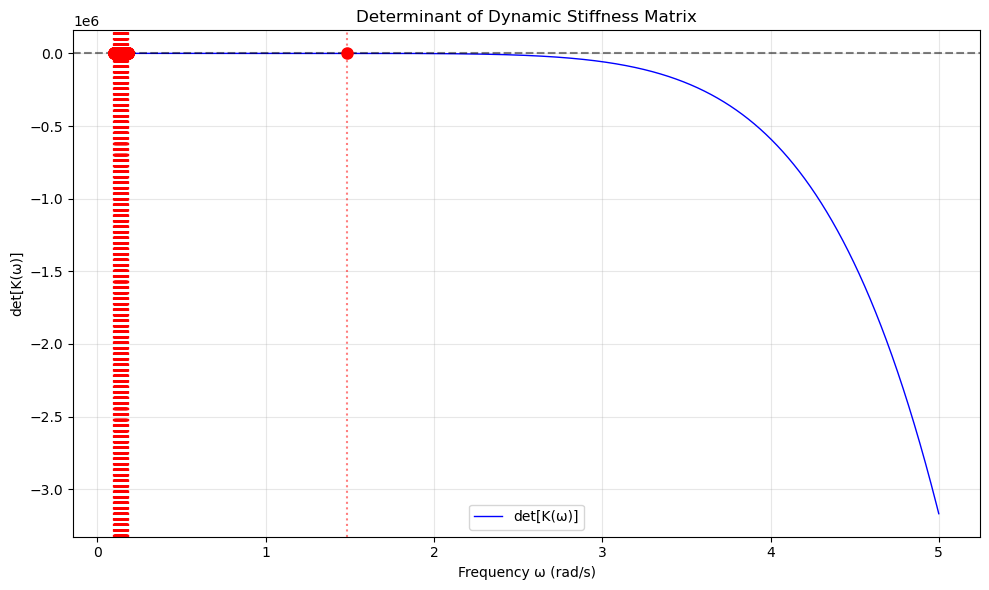

Found 331 natural frequencies
Found complex roots: [-6.34832332e-05-1.48422247j -1.62632933e-03-1.48422158j
  7.81499703e-05-1.48422247j  1.66781760e-01-1.47482209j
  1.66781637e-01+1.4748221j  -3.48918774e-05+1.48422247j
  1.53018350e-03+1.48422168j  2.40260717e-04-1.48422245j
 -1.47778031e-01-1.47684732j -1.00493440e-01-1.48081647j
  1.23487224e-01-1.47907649j -7.90345109e-03-1.48420143j
 -7.90338659e-03+1.48420143j -2.17702359e-01+1.46816962j
  1.23486819e-01+1.47907652j -1.00873971e-01+1.4807906j
 -1.47627177e-01+1.47686241j -6.94457753e-04+1.48422231j
 -2.09695745e-01-1.46933456j -1.68054809e-02-1.48412733j
  1.44116746e-03-1.48422177j  1.35376262e-02-1.48416073j
  1.06763563e-03-1.48422209j -1.95155588e-04-1.48422246j
  8.00260177e-01-1.25j        8.00260177e-01+1.25j
  1.21901008e-03+1.48422197j  1.34974239e-02+1.4841611j
  3.66140036e-04+1.48422243j  2.14687049e-04+1.48422246j
 -1.71349002e-02+1.48412356j -2.09702753e-01+1.46933356j
  8.09252234e-02-1.48201466j -1.15947185e-01-

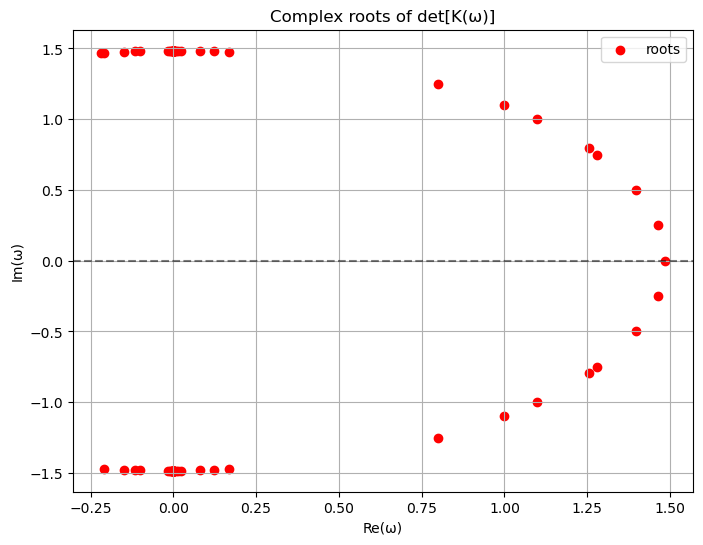

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(omega_grid, f_grid, 'b-', linewidth=1, label='det[K(ω)]')
plt.axhline(y=0, color='k', linestyle='--', alpha=0.5)

# Mark found roots
for r in omega_n:
    plt.axvline(x=r, color='r', linestyle=':', alpha=0.5)
    plt.plot(r, 0, 'ro', markersize=8)

plt.xlabel('Frequency ω (rad/s)')
plt.ylabel('det[K(ω)]')
plt.title('Determinant of Dynamic Stiffness Matrix')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Found {len(omega_n)} natural frequencies")

# -----------------------------
# Find complex roots of det(K) in the complex ω-plane
# -----------------------------
from scipy.optimize import root

def F_xy(xy):
    om = xy[0] + 1j*xy[1]
    val = detK_numeric(om)
    return [np.real(val), np.imag(val)]

# Grid of initial guesses (adjust ranges if needed)
re_vals = np.linspace(0.1, 5.0, 20)
im_vals = np.linspace(-3.0, 3.0, 25)
roots_complex = []

for xr in re_vals:
    for yi in im_vals:
        guess = [xr, yi]
        try:
            sol = root(F_xy, guess, tol=1e-8, method='hybr')
            if sol.success:
                x,y = sol.x
                omc = x + 1j*y
                res = detK_numeric(omc)
                if abs(res) < 1e-6:
                    # Uniqueness filter
                    if not any(abs(omc - r) < 1e-4 for r in roots_complex):
                        roots_complex.append(omc)
        except Exception:
            pass

roots_complex = np.array(roots_complex)
print('Found complex roots:', roots_complex)

# Plot complex roots in the complex plane
plt.figure(figsize=(8,6))
if roots_complex.size > 0:
    plt.scatter(roots_complex.real, roots_complex.imag, c='r', label='roots')
else:
    plt.text(0.5, 0.5, 'No complex roots found in search region', transform=plt.gca().transAxes)
plt.axhline(0,color='k',linestyle='--',alpha=0.5)
plt.xlabel('Re(ω)')
plt.ylabel('Im(ω)')
plt.title('Complex roots of det[K(ω)]')
plt.grid(True)
plt.legend()
# Annotate only if not too many roots
if roots_complex.size > 0 and roots_complex.size <= 20:
    for omc in roots_complex:
        plt.annotate(f"{omc.real:.3f}{omc.imag:+.3f}j", (omc.real, omc.imag))
plt.show()

First three natural frequencies [rad/s]: [0.1        0.10024501 0.10049002]
First three natural frequencies [Hz]: [0.01591549 0.01595449 0.01599348]


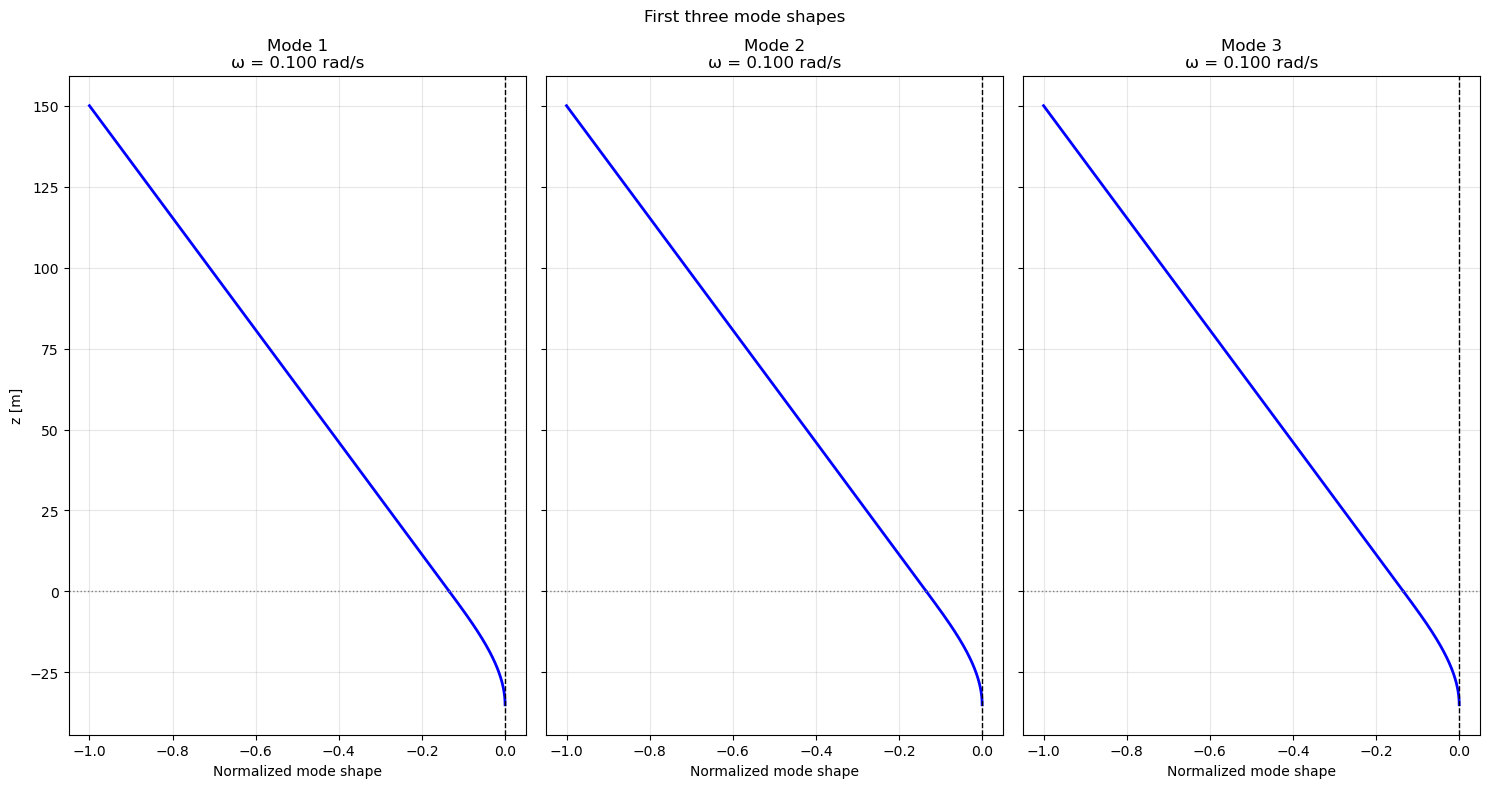

In [32]:
import matplotlib.pyplot as plt

# Select first three non-zero natural frequencies
omega_positive = np.array([om for om in np.real(omega_n) if om > 1e-6], dtype=float)
omega_3 = omega_positive[:3]

print('First three natural frequencies [rad/s]:', omega_3)
print('First three natural frequencies [Hz]:', omega_3/(2*np.pi))

# z-grids for plotting
z1_grid = np.linspace(-h_num, 0.0, 250)    # submerged part
z2_grid = np.linspace(0.0, H_num, 350)     # above-water part

fig, axes = plt.subplots(1, 3, figsize=(15, 8), sharey=True)

for i, wn in enumerate(omega_3):
    # Compute modal coefficient vector from nullspace approximation of K(wn)
    K_eval = np.array(K_func(wn), dtype=np.complex128)
    _, _, Vh = np.linalg.svd(K_eval)
    Cn = Vh[-1, :]

    subsdict = dict(zip(Cvec, Cn))
    phi1_sym = W1.subs(subsdict).subs(vals).subs(omega, float(wn))
    phi2_sym = W2.subs(subsdict).subs(vals).subs(omega, float(wn))

    phi1_fun = sp.lambdify(z, phi1_sym, modules='numpy')
    phi2_fun = sp.lambdify(z, phi2_sym, modules='numpy')

    phi1_vals = np.real(np.array(phi1_fun(z1_grid), dtype=np.complex128))
    phi2_vals = np.real(np.array(phi2_fun(z2_grid), dtype=np.complex128))

    # Normalize each mode by global max absolute value
    mode_max = max(np.max(np.abs(phi1_vals)), np.max(np.abs(phi2_vals)))
    if mode_max > 0:
        phi1_vals = phi1_vals / mode_max
        phi2_vals = phi2_vals / mode_max

    ax = axes[i]
    ax.plot(phi1_vals, z1_grid, 'b', linewidth=2)
    ax.plot(phi2_vals, z2_grid, 'b', linewidth=2)
    ax.axvline(0.0, color='k', linestyle='--', linewidth=1)
    ax.axhline(0.0, color='gray', linestyle=':', linewidth=1)
    ax.set_title(f'Mode {i+1}\nω = {wn:.3f} rad/s')
    ax.set_xlabel('Normalized mode shape')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('z [m]')
fig.suptitle('First three mode shapes', y=0.98)
plt.tight_layout()
plt.show()